In [ ]:
import os
import glob
import math
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import math
from glob import glob

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from torchvision.utils import make_grid
import torch.backends.cudnn as cudnn
from torch.utils.data import DataLoader, random_split, Dataset, Subset

# For metric calculations
from torchmetrics.image import StructuralSimilarityIndexMeasure
from torchmetrics.image.fid import FrechetInceptionDistance
from PIL import Image

# Device setup
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
cudnn.benchmark = True

Using device: cuda:0


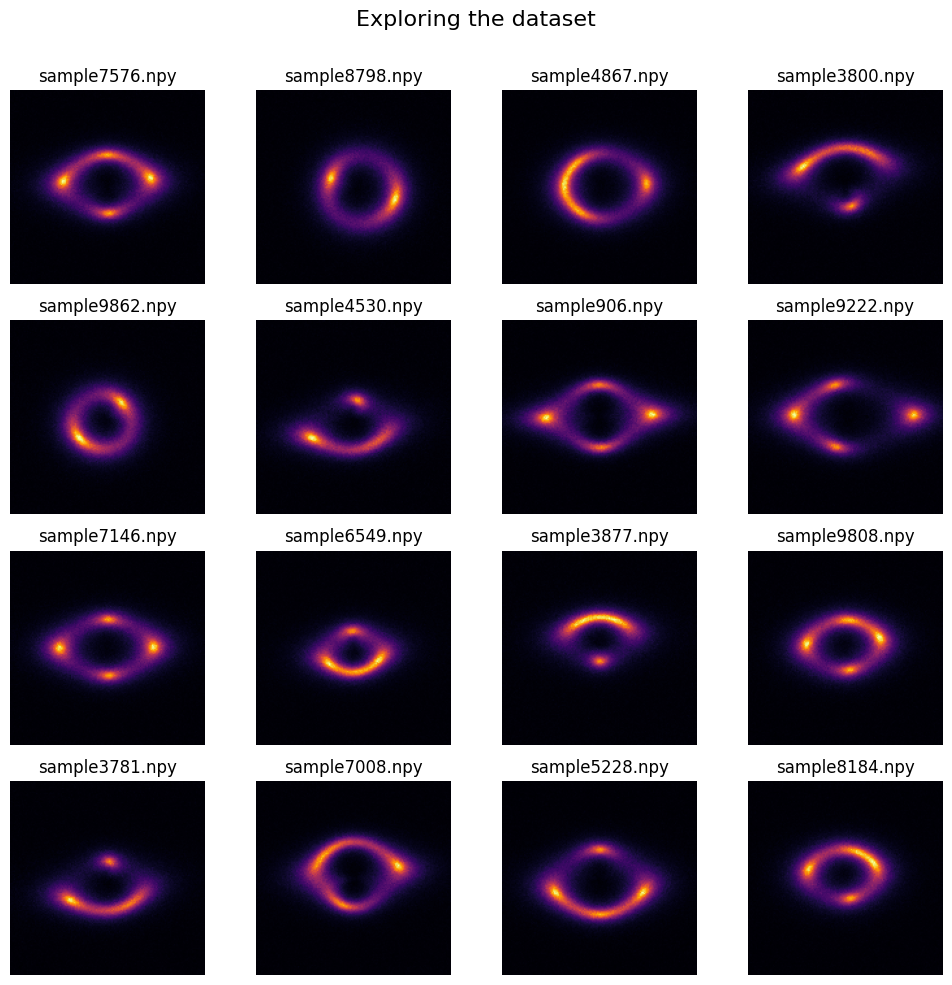

In [ ]:
directory = "/teamspace/studios/this_studio/Samples"

# Get list of .npy files
npy_files = [f for f in os.listdir(directory) if f.endswith('.npy')]
npy_files = npy_files[:16]  # Take first 16 files for 4x4 grid

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("Exploring the dataset", fontsize=16)

for i, ax in enumerate(axes.flat):
    if i < len(npy_files):
        file_path = os.path.join(directory, npy_files[i])
        image = np.load(file_path).squeeze(0)
        
        ax.imshow(image, cmap='inferno')
        ax.set_title(npy_files[i])
    
    ax.axis("off")

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

In [ ]:
class diff_Dataset(Dataset):
    """
    Custom dataset class for loading .npy files of shape (1, 64, 64).
    Assumes all .npy files are stored in a single directory with no labels.
    """
    def __init__(self, im_path):
        """
        Initialize the dataset.

        :param im_path: Path to the directory containing .npy files.
        """
        assert os.path.exists(im_path), f"Data path {im_path} does not exist"
        self.im_path = im_path
        self.files = sorted(glob(os.path.join(im_path, "*.npy")))
        print(f"Found {len(self.files)} .npy files")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):
        npy_file = self.files[index]
        array = np.load(npy_file)  # shape (1, 150, 150)
        tensor = torch.from_numpy(array).float()

        # normalize from [0, 1] to [-1, 1] if data is already in 0-1 range
        tensor = (2 * tensor) - 1

        return tensor


In [ ]:
# 1. Load the full dataset
filepath = '/teamspace/studios/this_studio/Samples'
full_dataset = diff_Dataset(filepath)

# 2. Define the exact split sizes
train_size = 9000
val_size = 700
test_size = 300

# 3. Perform the random split (using a seed for reproducibility)
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, 
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# 4. Create the DataLoaders
# Pin memory speeds up CPU to GPU transfers
batch_size = 32 # Adjusted based on the GPU used (L4)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

print(f"Data successfully split! Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Found 10000 .npy files
Data successfully split! Train: 9000, Val: 700, Test: 300


In [ ]:
# Sanity check
train_loader.dataset[0].shape

torch.Size([1, 150, 150])

### VAE 

In [6]:
def simple_vae_loss(pred, target, mu, log_var, kl_weight=0.001):
    """Standard Beta-VAE Loss for smooth image reconstruction"""
    
    # 1. Standard MSE Loss (Perfect for smooth gradients like lenses)
    # Using 'mean' keeps the loss values stable across different batch sizes
    recon_loss = F.mse_loss(pred, target, reduction='mean')
    
    # 2. KL Divergence (Forces the latent space into a neat normal distribution)
    # The mean here balances it against the mean of the recon_loss
    kl_loss = torch.mean(-0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp(), dim=[1, 2, 3]))
    
    # Total loss (kl_weight acts as the 'Beta' parameter)
    total_loss = recon_loss + (kl_weight * kl_loss)
    
    return total_loss, recon_loss, kl_loss

In [ ]:
class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.GroupNorm(8, channels),
            nn.LeakyReLU(0.2),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.GroupNorm(8, channels),
            nn.LeakyReLU(0.2),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        )
    def forward(self, x):
        return x + self.block(x)

class Sharp_LDM_VAE(nn.Module):
    def __init__(self, in_channels=1, latent_channels=3, base_dim=32): 
        super().__init__()
        
        # ==========================================
        # ENCODER (Expects 256x256 Padded Input)
        # ==========================================
        self.encoder_in = nn.Conv2d(in_channels, base_dim, kernel_size=3, padding=1)
        
        # 256 -> 128
        self.enc_down1 = nn.Sequential(
            ResBlock(base_dim),
            nn.Conv2d(base_dim, base_dim*2, kernel_size=4, stride=2, padding=1)
        )
        # 128 -> 64
        self.enc_down2 = nn.Sequential(
            ResBlock(base_dim*2),
            nn.Conv2d(base_dim*2, base_dim*4, kernel_size=4, stride=2, padding=1)
        )
        # 64 -> 32
        self.enc_down3 = nn.Sequential(
            ResBlock(base_dim*4),
            nn.Conv2d(base_dim*4, base_dim*4, kernel_size=4, stride=2, padding=1)
        )
        
        # Outputs 32x32
        # Also latent channels*2 as we want the features for both mean and variance
        self.enc_out = nn.Conv2d(base_dim*4, latent_channels * 2, kernel_size=3, padding=1) 

        # ==========================================
        # DECODER (Expects 32x32 Input)
        # ==========================================
        self.decoder_in = nn.Conv2d(latent_channels, base_dim*4, kernel_size=3, padding=1)
        
        # 32 -> 64 
        self.dec_up1 = nn.Sequential(
            ResBlock(base_dim*4),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(base_dim*4, base_dim*4, kernel_size=3, padding=1) 
        )
        # 64 -> 128
        self.dec_up2 = nn.Sequential(
            ResBlock(base_dim*4),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(base_dim*4, base_dim*2, kernel_size=3, padding=1) 
        )
        # 128 -> 256
        self.dec_up3 = nn.Sequential(
            ResBlock(base_dim*2),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(base_dim*2, base_dim, kernel_size=3, padding=1) 
        )
        
        self.dec_out = nn.Conv2d(base_dim, in_channels, kernel_size=3, padding=1)

    def encode(self, x):
        x = self.encoder_in(x)
        x = self.enc_down1(x)
        x = self.enc_down2(x)
        x = self.enc_down3(x)
        x = self.enc_out(x)
        mu, log_var = torch.chunk(x, 2, dim=1)
        log_var = torch.clamp(log_var, min=-30.0, max=20.0)
        return mu, log_var

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var) 
        eps = torch.randn_like(std)    
        return mu + eps * std            

    def decode(self, z):
        z = self.decoder_in(z)
        z = self.dec_up1(z)
        z = self.dec_up2(z)
        z = self.dec_up3(z)
        return self.dec_out(z)
        
    def forward(self, x):
        # Padding 150x150 -> 256x256 (Add 53 pixels to left, right, top, bottom)
        x_padded = F.pad(x, (53, 53, 53, 53), mode='constant', value=-1.0) # -1.0 is black in our normalized space
        
        # VAE pass
        mu, log_var = self.encode(x_padded)
        z = self.reparameterize(mu, log_var)
        recon_padded = self.decode(z)
        
        # CROP 256x256 -> 150x150 (Slice out the exact center) which is the original resolution
        reconstructed = recon_padded[:, :, 53:203, 53:203]
        
        return reconstructed, mu, log_var

In [ ]:
def train_vae(train_loader, val_loader, epochs=50, kl_weight=1e-4, device='cuda'):
    print("--- Training Sharp LDM-Ready VAE ---")
    
    # directory to hold the per-epoch checkpoints
    checkpoint_dir = 'checkpoints'
    os.makedirs(checkpoint_dir, exist_ok=True)
    
    vae = Sharp_LDM_VAE(in_channels=1, latent_channels=3, base_dim=32).to(device)
    optimizer = optim.Adam(vae.parameters(), lr=1e-4)
    
    best_val_loss = float('inf')
    best_model_path = 'best_ldm_vae_ckpt.pth' 
    
    for epoch in range(epochs):
        # ==========================================
        #              TRAINING PHASE
        # ==========================================
        vae.train()
        train_losses = []
        train_recon = []
        train_kl = []
        
        with tqdm(train_loader, desc=f"VAE Train Epoch {epoch+1}/{epochs}") as pbar:
            for im in pbar:
                im = im.float().to(device)
                optimizer.zero_grad()
                
                reconstructed, mu, log_var = vae(im)
                
                loss, recon_loss, kl_loss = simple_vae_loss(
                    reconstructed, im, mu, log_var, kl_weight=kl_weight
                ) 
                
                loss.backward()
                torch.nn.utils.clip_grad_norm_(vae.parameters(), max_norm=1.0)
                optimizer.step()
                
                train_losses.append(loss.item())
                train_recon.append(recon_loss.item())
                train_kl.append(kl_loss.item())
                
                pbar.set_postfix(
                    Loss=f'{loss.item():.4f}', 
                    Recon=f'{recon_loss.item():.4f}', 
                    KL=f'{kl_loss.item():.6f}'
                )
                
        avg_train_loss = np.mean(train_losses)
        
        # ==========================================
        #              VALIDATION PHASE
        # ==========================================
        vae.eval()
        val_losses = []
        with torch.no_grad():
            with tqdm(val_loader, desc=f"VAE Val Epoch {epoch+1}/{epochs}", leave=False) as pbar:
                for im in pbar:
                    im = im.float().to(device)
                    reconstructed, mu, log_var = vae(im)
                    
                    val_loss, _, _ = simple_vae_loss(
                        reconstructed, im, mu, log_var, kl_weight=kl_weight
                    )
                    val_losses.append(val_loss.item())
                    
        avg_val_loss = np.mean(val_losses)
        avg_train_recon = np.mean(train_recon)
        avg_train_kl = np.mean(train_kl)
        
        print(f"Epoch {epoch+1} Summary | Train Loss: {avg_train_loss:.4f} (Recon: {avg_train_recon:.4f}, KL: {avg_train_kl:.6f}) | Val Loss: {avg_val_loss:.4f}")
        
        # saving checkpoints and best model
        epoch_model_path = os.path.join(checkpoint_dir, f'ldm_vae_epoch_{epoch+1}.pth')
        torch.save(vae.state_dict(), epoch_model_path)
        
        # overwrite the "best" model if the validation loss actually improved
        if avg_val_loss < best_val_loss:
            print(f"  --> Validation loss decreased ({best_val_loss:.4f} -> {avg_val_loss:.4f}). Saving BEST model...")
            best_val_loss = avg_val_loss
            torch.save(vae.state_dict(), best_model_path)
            
    print(f"\nTraining Complete. Best Validation Loss: {best_val_loss:.4f}")
    
    # load the best weights before returning
    vae.load_state_dict(torch.load(best_model_path, map_location=device))
    return vae

In [ ]:
# ==========================================
# TESTING PHASE
# ==========================================
def test_vae(vae_model, test_loader, kl_weight=0.001, device='cuda'):
    print("\n--- Testing Best LDM-Ready VAE ---")
    vae_model.eval()
    test_losses = []
    
    with torch.no_grad():
        for im in tqdm(test_loader, desc="Testing Model"):
            im = im.float().to(device)
            
            # Forward pass
            reconstructed, mu, log_var = vae_model(im)
            
            loss, recon_loss, kl_loss = simple_vae_loss(
                reconstructed, im, mu, log_var, kl_weight=kl_weight
            )
            test_losses.append(loss.item())
            
    avg_test_loss = np.mean(test_losses)
    print(f"Final Test Loss on {len(test_loader.dataset)} unseen images: {avg_test_loss:.6f}")
    return avg_test_loss

# running all the defined functions now
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Hyperparameters
num_epochs = 25       
kl_weight_val = 5e-5 

best_vae_model = train_vae(
    train_loader=train_loader, 
    val_loader=val_loader, 
    epochs=num_epochs, 
    kl_weight=kl_weight_val,
    device=device
)

# run the final test on the unseen dataset
final_test_loss = test_vae(
    vae_model=best_vae_model, 
    test_loader=test_loader, 
    kl_weight=kl_weight_val, 
    device=device
)

--- Training Sharp LDM-Ready VAE ---


VAE Train Epoch 1/25:   0%|          | 0/282 [00:00<?, ?it/s]

VAE Train Epoch 1/25: 100%|██████████| 282/282 [01:47<00:00,  2.62it/s, KL=95.436722, Loss=0.0077, Recon=0.0029] 


Epoch 1 Summary | Train Loss: 0.0181 (Recon: 0.0124, KL: 113.602019) | Val Loss: 0.0084
  --> Validation loss decreased (inf -> 0.0084). Saving BEST model...


VAE Train Epoch 2/25: 100%|██████████| 282/282 [01:45<00:00,  2.68it/s, KL=82.001526, Loss=0.0066, Recon=0.0025] 


...

Epoch 24 Summary | Train Loss: 0.0052 (Recon: 0.0018, KL: 67.524251) | Val Loss: 0.0052


VAE Train Epoch 25/25: 100%|██████████| 282/282 [01:47<00:00,  2.63it/s, KL=62.510727, Loss=0.0046, Recon=0.0014]


Epoch 25 Summary | Train Loss: 0.0052 (Recon: 0.0018, KL: 67.059208) | Val Loss: 0.0052

Training Complete. Best Validation Loss: 0.0051

--- Testing Best LDM-Ready VAE ---


Testing Model: 100%|██████████| 10/10 [00:01<00:00,  5.50it/s]

Final Test Loss on 300 unseen images: 0.005122



--- Calculating VAE Latent Statistics ---


Gathering Statistics:  10%|█         | 1/10 [00:00<00:02,  3.84it/s]

Gathering Statistics: 100%|██████████| 10/10 [00:01<00:00,  7.70it/s]


--- VAE Latent Space Statistics ---
Latent Mean: 0.000981
Latent Std Dev: 0.162196
RECOMMENDED SCALE FACTOR: 6.165381
-----------------------------------

--- Generating Visualizations ---


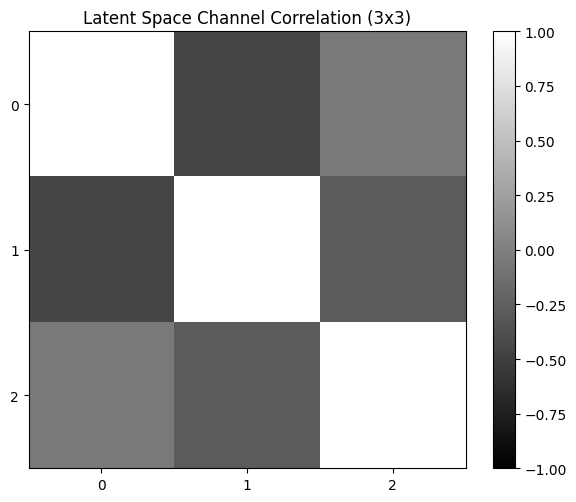

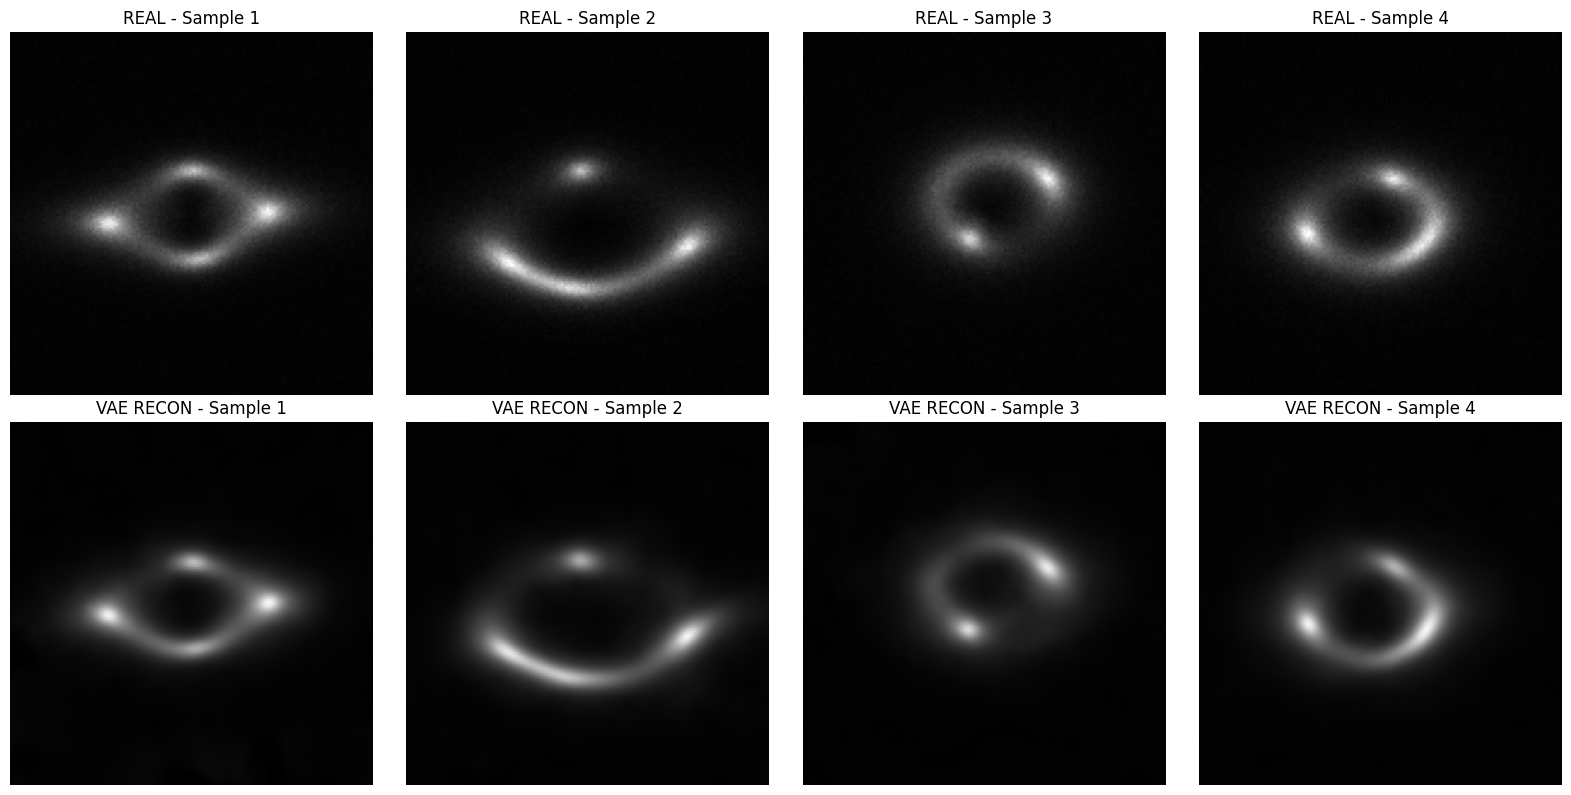

In [ ]:
def test_vae_and_visualize_grayscale(vae_model, test_loader, device='cuda'):
    print("\n--- Calculating VAE Latent Statistics ---")
    vae_model.eval()
    
    sum_latents = 0.0
    sum_sq_latents = 0.0
    total_elements = 0
    
    with torch.no_grad():
        for im in tqdm(test_loader, desc="Gathering Statistics"):
            im = im.float().to(device)
            
            reconstructed, mu, _ = vae_model(im)
            
            sum_latents += mu.sum().item()
            sum_sq_latents += (mu ** 2).sum().item()
            total_elements += mu.numel()
            
    global_mean = sum_latents / total_elements
    global_variance = (sum_sq_latents / total_elements) - (global_mean ** 2)
    global_std = np.sqrt(global_variance)
    scale_factor = 1.0 / global_std
    
    print("\n--- VAE Latent Space Statistics ---")
    print(f"Latent Mean: {global_mean:.6f}")
    print(f"Latent Std Dev: {global_std:.6f}")
    print(f"RECOMMENDED SCALE FACTOR: {scale_factor:.6f}")
    print("-" * 35)
    
    print("\n--- Generating Visualizations ---")
    # Grab one batch of real data
    real_images = next(iter(test_loader)).float().to(device)
    
    with torch.no_grad():
        reconstructed_images, mu, _ = vae_model(real_images)
        
    # 1. CALCULATE LATENT CORRELATION MATRIX (3x3)
    # Using strict grayscale for the correlation matrix plot
    mu_np = mu.cpu().numpy()
    latent_channels = mu_np.shape[1]
    mu_flat = mu_np.transpose(1, 0, 2, 3).reshape(latent_channels, -1)
    latent_corr = np.corrcoef(mu_flat)
    
    # Plot Latent Correlation Matrix (Grayscale)
    fig_corr, ax_corr = plt.subplots(figsize=(6, 5))
    # CHANGE: Swapped 'coolwarm' for 'gray'
    im_c = ax_corr.imshow(latent_corr, cmap='gray', vmin=-1, vmax=1)
    ax_corr.set_title("Latent Space Channel Correlation (3x3)")
    ax_corr.set_xticks(range(latent_channels))
    ax_corr.set_yticks(range(latent_channels))
    fig_corr.colorbar(im_c, ax=ax_corr)
    plt.tight_layout()
    plt.show()
    
    # 2. PLOT IMAGE VISUALIZATIONS (Comparing multiple samples)
    # Shift data from [-1, 1] back to [0, 1] for proper grayscale plotting
    real_plot = (real_images.cpu().numpy() + 1.0) / 2.0
    recon_plot = (reconstructed_images.cpu().numpy() + 1.0) / 2.0
    
    num_samples = min(real_plot.shape[0], 4) # Plot up to 4 lenses
    fig_img, axes_img = plt.subplots(2, num_samples, figsize=(4 * num_samples, 8))
    
    for i in range(num_samples):
        # Top Row: Real Images
        ax_real = axes_img[0, i]
        # CHANGE: Swapped 'magma' for 'gray'
        im1 = ax_real.imshow(real_plot[i, 0, :, :], cmap='gray', vmin=0, vmax=1)
        ax_real.set_title(f"REAL - Sample {i+1}")
        ax_real.axis('off')
        
        # Bottom Row: Reconstructed Images
        ax_recon = axes_img[1, i]
        # CHANGE: Swapped 'magma' for 'gray'
        im2 = ax_recon.imshow(recon_plot[i, 0, :, :], cmap='gray', vmin=0, vmax=1)
        ax_recon.set_title(f"VAE RECON - Sample {i+1}")
        ax_recon.axis('off')

    plt.tight_layout()
    plt.show() 
    
    return scale_factor

# ==========================================
# EXECUTION
# ==========================================
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 1. Initialize the model (Ensure you use the NEW Simple_LDM_VAE class)
best_vae_model = Sharp_LDM_VAE(in_channels=1, latent_channels=3, base_dim=32).to(device)

# 2. Load the trained weights
best_model_path = 'best_ldm_vae_ckpt.pth'
best_vae_model.load_state_dict(torch.load(best_model_path, map_location=device))

# 3. Run the updated grayscale evaluation
new_scale_factor = test_vae_and_visualize_grayscale(best_vae_model, test_loader, device=device)

In [8]:
def get_time_embedding(time_steps, temb_dim):
    """
    Convert time steps tensor into an embedding using the
    sinusoidal time embedding formula
    :param time_steps: 1D tensor of length batch size
    :param temb_dim: Dimension of the embedding
    :return: BxD embedding representation of B time steps
    """
    assert temb_dim % 2 == 0, "time embedding dimension must be divisible by 2"

    # factor = 10000^(2i/d_model)
    factor = 10000 ** (
        torch.arange(
            start=0, 
            end=temb_dim // 2, 
            dtype=torch.float32, 
            device=time_steps.device
        ) / (temb_dim // 2)
    )

    # pos / factor
    t_emb = time_steps[:, None].repeat(1, temb_dim // 2) / factor
    t_emb = torch.cat([torch.sin(t_emb), torch.cos(t_emb)], dim=-1)
    return t_emb


class DownBlock(nn.Module):
    """
    Down conv block with attention.
    Sequence of:
      1. Resnet block with time embedding
      2. Attention block
      3. Downsample using 2x2 average pooling (or Conv2d strided)
    """
    def __init__(self, in_channels, out_channels, t_emb_dim,
                 down_sample=True, num_heads=4, num_layers=1):
        super().__init__()
        self.num_layers = num_layers
        self.down_sample = down_sample
        self.resnet_conv_first = nn.ModuleList(
            [
                nn.Sequential(
                    nn.GroupNorm(8, in_channels if i == 0 else out_channels),
                    nn.SiLU(),
                    nn.Conv2d(in_channels if i == 0 else out_channels, 
                              out_channels,
                              kernel_size=3, stride=1, padding=1),
                )
                for i in range(num_layers)
            ]
        )
        self.t_emb_layers = nn.ModuleList([
            nn.Sequential(
                nn.SiLU(),
                nn.Linear(t_emb_dim, out_channels)
            )
            for _ in range(num_layers)
        ])
        self.resnet_conv_second = nn.ModuleList(
            [
                nn.Sequential(
                    nn.GroupNorm(8, out_channels),
                    nn.SiLU(),
                    nn.Conv2d(out_channels, out_channels,
                              kernel_size=3, stride=1, padding=1),
                )
                for _ in range(num_layers)
            ]
        )
        self.attention_norms = nn.ModuleList(
            [nn.GroupNorm(8, out_channels)
             for _ in range(num_layers)]
        )

        self.attentions = nn.ModuleList(
            [nn.MultiheadAttention(out_channels, num_heads, batch_first=True)
             for _ in range(num_layers)]
        )
        self.residual_input_conv = nn.ModuleList(
            [
                nn.Conv2d(in_channels if i == 0 else out_channels, out_channels, kernel_size=1)
                for i in range(num_layers)
            ]
        )
        self.down_sample_conv = (
            nn.Conv2d(out_channels, out_channels, 4, 2, 1) 
            if self.down_sample else nn.Identity()
        )

    def forward(self, x, t_emb):
        out = x
        for i in range(self.num_layers):
            # Resnet block of UNet
            resnet_input = out
            out = self.resnet_conv_first[i](out)
            out = out + self.t_emb_layers[i](t_emb)[:, :, None, None]
            out = self.resnet_conv_second[i](out)
            out = out + self.residual_input_conv[i](resnet_input)

            # Attention block of UNet
            batch_size, channels, h, w = out.shape
            in_attn = out.reshape(batch_size, channels, h * w)
            in_attn = self.attention_norms[i](in_attn)
            in_attn = in_attn.transpose(1, 2)
            out_attn, _ = self.attentions[i](in_attn, in_attn, in_attn)
            out_attn = out_attn.transpose(1, 2).reshape(batch_size, channels, h, w)
            out = out + out_attn

        out = self.down_sample_conv(out)
        return out


class MidBlock(nn.Module):
    """
    Mid conv block with attention.
    Sequence of:
      1. Resnet block with time embedding
      2. Attention block
      3. Resnet block with time embedding
    """
    def __init__(self, in_channels, out_channels, t_emb_dim, num_heads=4, num_layers=1):
        super().__init__()
        self.num_layers = num_layers
        self.resnet_conv_first = nn.ModuleList(
            [
                nn.Sequential(
                    nn.GroupNorm(8, in_channels if i == 0 else out_channels),
                    nn.SiLU(),
                    nn.Conv2d(in_channels if i == 0 else out_channels, 
                              out_channels, kernel_size=3, stride=1, padding=1),
                )
                for i in range(num_layers + 1)
            ]
        )
        self.t_emb_layers = nn.ModuleList([
            nn.Sequential(
                nn.SiLU(),
                nn.Linear(t_emb_dim, out_channels)
            )
            for _ in range(num_layers + 1)
        ])
        self.resnet_conv_second = nn.ModuleList(
            [
                nn.Sequential(
                    nn.GroupNorm(8, out_channels),
                    nn.SiLU(),
                    nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
                )
                for _ in range(num_layers + 1)
            ]
        )

        self.attention_norms = nn.ModuleList(
            [nn.GroupNorm(8, out_channels)
             for _ in range(num_layers)]
        )

        self.attentions = nn.ModuleList(
            [nn.MultiheadAttention(out_channels, num_heads, batch_first=True)
             for _ in range(num_layers)]
        )
        self.residual_input_conv = nn.ModuleList(
            [
                nn.Conv2d(in_channels if i == 0 else out_channels, 
                          out_channels, kernel_size=1)
                for i in range(num_layers + 1)
            ]
        )

    def forward(self, x, t_emb):
        out = x

        # First resnet block
        resnet_input = out
        out = self.resnet_conv_first[0](out)
        out = out + self.t_emb_layers[0](t_emb)[:, :, None, None]
        out = self.resnet_conv_second[0](out)
        out = out + self.residual_input_conv[0](resnet_input)

        for i in range(self.num_layers):
            # Attention Block
            batch_size, channels, h, w = out.shape
            in_attn = out.reshape(batch_size, channels, h * w)
            in_attn = self.attention_norms[i](in_attn)
            in_attn = in_attn.transpose(1, 2)
            out_attn, _ = self.attentions[i](in_attn, in_attn, in_attn)
            out_attn = out_attn.transpose(1, 2).reshape(batch_size, channels, h, w)
            out = out + out_attn

            # Resnet Block
            resnet_input = out
            out = self.resnet_conv_first[i + 1](out)
            out = out + self.t_emb_layers[i + 1](t_emb)[:, :, None, None]
            out = self.resnet_conv_second[i + 1](out)
            out = out + self.residual_input_conv[i + 1](resnet_input)

        return out


class UpBlock(nn.Module):
    """
    Up conv block with attention.
    Sequence of:
      1. Upsample
      2. Concatenate Down block output
      3. Resnet block with time embedding
      4. Attention Block
    """
    def __init__(self, in_channels, out_channels, t_emb_dim,
                 up_sample=True, num_heads=4, num_layers=1):
        super().__init__()
        self.num_layers = num_layers
        self.up_sample = up_sample
        self.resnet_conv_first = nn.ModuleList(
            [
                nn.Sequential(
                    nn.GroupNorm(8, in_channels if i == 0 else out_channels),
                    nn.SiLU(),
                    nn.Conv2d(in_channels if i == 0 else out_channels, 
                              out_channels, kernel_size=3, stride=1, padding=1),
                )
                for i in range(num_layers)
            ]
        )
        self.t_emb_layers = nn.ModuleList([
            nn.Sequential(
                nn.SiLU(),
                nn.Linear(t_emb_dim, out_channels)
            )
            for _ in range(num_layers)
        ])
        self.resnet_conv_second = nn.ModuleList(
            [
                nn.Sequential(
                    nn.GroupNorm(8, out_channels),
                    nn.SiLU(),
                    nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
                )
                for _ in range(num_layers)
            ]
        )

        self.attention_norms = nn.ModuleList(
            [nn.GroupNorm(8, out_channels) for _ in range(num_layers)]
        )

        self.attentions = nn.ModuleList(
            [nn.MultiheadAttention(out_channels, num_heads, batch_first=True)
             for _ in range(num_layers)]
        )
        self.residual_input_conv = nn.ModuleList(
            [
                nn.Conv2d(in_channels if i == 0 else out_channels, 
                          out_channels, kernel_size=1)
                for i in range(num_layers)
            ]
        )
        self.up_sample_conv = (
            nn.ConvTranspose2d(in_channels // 2, in_channels // 2, 4, 2, 1) 
            if self.up_sample else nn.Identity()
        )

    def forward(self, x, out_down, t_emb):
        x = self.up_sample_conv(x)
        x = torch.cat([x, out_down], dim=1)

        out = x
        for i in range(self.num_layers):
            resnet_input = out
            out = self.resnet_conv_first[i](out)
            out = out + self.t_emb_layers[i](t_emb)[:, :, None, None]
            out = self.resnet_conv_second[i](out)
            out = out + self.residual_input_conv[i](resnet_input)

            batch_size, channels, h, w = out.shape
            in_attn = out.reshape(batch_size, channels, h * w)
            in_attn = self.attention_norms[i](in_attn)
            in_attn = in_attn.transpose(1, 2)
            out_attn, _ = self.attentions[i](in_attn, in_attn, in_attn)
            out_attn = out_attn.transpose(1, 2).reshape(batch_size, channels, h, w)
            out = out + out_attn

        return out


class Unet(nn.Module):
    """
    UNet model comprising Down blocks, Mid blocks, and Up blocks.
    """
    def __init__(self, model_config):
        super().__init__()
        im_channels = model_config['im_channels']
        self.down_channels = model_config['down_channels']
        self.mid_channels = model_config['mid_channels']
        self.t_emb_dim = model_config['time_emb_dim']
        self.down_sample = model_config['down_sample']
        self.num_down_layers = model_config['num_down_layers']
        self.num_mid_layers = model_config['num_mid_layers']
        self.num_up_layers = model_config['num_up_layers']

        assert self.mid_channels[0] == self.down_channels[-1]
        assert self.mid_channels[-1] == self.down_channels[-2]
        assert len(self.down_sample) == len(self.down_channels) - 1

        # Initial projection from sinusoidal time embedding
        self.t_proj = nn.Sequential(
            nn.Linear(self.t_emb_dim, self.t_emb_dim),
            nn.SiLU(),
            nn.Linear(self.t_emb_dim, self.t_emb_dim)
        )

        self.up_sample = list(reversed(self.down_sample))
        self.conv_in = nn.Conv2d(im_channels, self.down_channels[0], 
                                 kernel_size=3, padding=1)

        self.downs = nn.ModuleList([])
        for i in range(len(self.down_channels) - 1):
            self.downs.append(
                DownBlock(
                    self.down_channels[i], 
                    self.down_channels[i + 1], 
                    self.t_emb_dim,
                    down_sample=self.down_sample[i], 
                    num_layers=self.num_down_layers
                )
            )

        self.mids = nn.ModuleList([])
        for i in range(len(self.mid_channels) - 1):
            self.mids.append(
                MidBlock(
                    self.mid_channels[i], 
                    self.mid_channels[i + 1], 
                    self.t_emb_dim,
                    num_layers=self.num_mid_layers
                )
            )

        self.ups = nn.ModuleList([])
        for i in reversed(range(len(self.down_channels) - 1)):
            self.ups.append(
                UpBlock(
                    self.down_channels[i] * 2, 
                    (self.down_channels[i - 1] if i != 0 else 16),
                    self.t_emb_dim, 
                    up_sample=self.down_sample[i], 
                    num_layers=self.num_up_layers
                )
            )

        self.norm_out = nn.GroupNorm(8, 16)
        self.conv_out = nn.Conv2d(16, im_channels, kernel_size=3, padding=1)

    def forward(self, x, t):
        # x: B x C x H x W
        out = self.conv_in(x)

        # Convert t -> embedding
        t_emb = get_time_embedding(torch.as_tensor(t).long(), self.t_emb_dim)
        t_emb = self.t_proj(t_emb)

        down_outs = []
        for idx, down in enumerate(self.downs):
            down_outs.append(out)
            out = down(out, t_emb)

        for mid in self.mids:
            out = mid(out, t_emb)

        for up in self.ups:
            down_out = down_outs.pop()
            out = up(out, down_out, t_emb)

        out = self.norm_out(out)
        out = nn.SiLU()(out)
        out = self.conv_out(out)
        return out


In [ ]:
class CosineNoiseScheduler:
    """
    Class for the cosine noise scheduler (Nichol & Dhariwal 2021).
    Ideal for Latent Diffusion Models.
    """
    def __init__(self, num_timesteps, s=0.008):
        self.num_timesteps = num_timesteps
        
        # 1. Define the cosine schedule for alpha_cum_prod (alpha_bar)
        steps = num_timesteps + 1
        x = torch.linspace(0, num_timesteps, steps)
        alphas_cumprod = torch.cos(((x / num_timesteps) + s) / (1 + s) * math.pi * 0.5) ** 2
        alphas_cumprod = alphas_cumprod / alphas_cumprod[0] # Normalize to start at 1.0
        
        # 2. Derive betas from alphas_cumprod
        betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
        
        # Clip beta to prevent singularity at the end of the diffusion process
        self.betas = torch.clip(betas, 0.0001, 0.999)
        
        # 3. Calculate standard DDPM variables
        self.alphas = 1.0 - self.betas
        self.alpha_cum_prod = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alpha_cum_prod = torch.sqrt(self.alpha_cum_prod)
        self.sqrt_one_minus_alpha_cum_prod = torch.sqrt(1.0 - self.alpha_cum_prod)

    def add_noise(self, original, noise, t):
        """
        Forward method for diffusion:
        x_t = sqrt(alpha_cum_prod) * x_0 + sqrt(1-alpha_cum_prod) * noise
        """
        original_shape = original.shape
        batch_size = original_shape[0]

        sqrt_alpha_cum_prod = self.sqrt_alpha_cum_prod.to(original.device)[t].reshape(batch_size)
        sqrt_one_minus_alpha_cum_prod = self.sqrt_one_minus_alpha_cum_prod.to(original.device)[t].reshape(batch_size)

        # Reshape (B,) -> (B,1,1,1) if image is (B,C,H,W)
        for _ in range(len(original_shape) - 1):
            sqrt_alpha_cum_prod = sqrt_alpha_cum_prod.unsqueeze(-1)
            sqrt_one_minus_alpha_cum_prod = sqrt_one_minus_alpha_cum_prod.unsqueeze(-1)

        return (
            sqrt_alpha_cum_prod * original + 
            sqrt_one_minus_alpha_cum_prod * noise
        )

    def sample_prev_timestep(self, xt, noise_pred, t):
        """
        Use the model's noise prediction to estimate x_{t-1}.
        """
        # Estimate x_0
        x0 = (
            (xt - self.sqrt_one_minus_alpha_cum_prod.to(xt.device)[t] * noise_pred) /
            torch.sqrt(self.alpha_cum_prod.to(xt.device)[t])
        )
        x0 = torch.clamp(x0, -1., 1.)

        # Mean of q(x_{t-1} | x_t, x_0)
        mean = (
            xt 
            - (self.betas.to(xt.device)[t] * noise_pred) 
            / (self.sqrt_one_minus_alpha_cum_prod.to(xt.device)[t])
        )
        mean = mean / torch.sqrt(self.alphas.to(xt.device)[t])

        if t == 0:
            return mean, x0
        else:
            variance = (
                (1 - self.alpha_cum_prod.to(xt.device)[t - 1]) /
                (1.0 - self.alpha_cum_prod.to(xt.device)[t])
            )
            variance = variance * self.betas.to(xt.device)[t]
            sigma = variance ** 0.5
            z = torch.randn(xt.shape).to(xt.device)
            return mean + sigma * z, x0

In [ ]:
def train_ldm(config, device='cuda'):
    # Extract sections of the config
    diffusion_config = config['diffusion_params']
    dataset_config   = config['dataset_params']
    model_config     = config['model_params']
    train_config     = config['train_params']
    ae_config        = config['autoencoder_params']

    # Create the noise scheduler
    # scheduler = LinearNoiseScheduler(
    #     num_timesteps=diffusion_config['num_timesteps'],
    #     beta_start=diffusion_config['beta_start'],
    #     beta_end=diffusion_config['beta_end']
    # )
    scheduler = CosineNoiseScheduler(num_timesteps=diffusion_config['num_timesteps'])

    # 1. Create the dataset and DataLoader
    full_dataset = diff_Dataset(dataset_config['im_path'])
    
    data_loader = DataLoader(full_dataset, 
                             batch_size=train_config['batch_size'], 
                             shuffle=True, 
                             num_workers=4,
                             pin_memory=True) # Added pin_memory for speed

    # ---> UPDATE 1: Initialize the new Sharp_LDM_VAE <---
    ae = Sharp_LDM_VAE(in_channels=1, latent_channels=3, base_dim=32).to(device)
    ae.load_state_dict(torch.load(ae_config['model_path'], map_location=device))
    ae.eval() # CRITICAL: Keep AE in eval mode

    # 3. Instantiate the UNet model & EMA Model
    model = Unet(model_config).to(device)
    model.train()
    
    # Create the EMA (Exponential Moving Average) shadow model
    ema_model = copy.deepcopy(model).eval()
    ema_decay = 0.995 

    # Create output directory
    if not os.path.exists(train_config['task_name']):
        os.makedirs(train_config['task_name'])

    # Load checkpoint if found
    ckpt_path = os.path.join(train_config['task_name'], train_config['ckpt_name'])
    ema_ckpt_path = os.path.join(train_config['task_name'], "ema_" + train_config['ckpt_name'])
    if os.path.exists(ckpt_path):
        print(f'Loading checkpoint from {ckpt_path}')
        model.load_state_dict(torch.load(ckpt_path, map_location=device))
        if os.path.exists(ema_ckpt_path):
            ema_model.load_state_dict(torch.load(ema_ckpt_path, map_location=device))

    # Optimizer, Loss, and Scheduler
    optimizer = optim.Adam(model.parameters(), lr=train_config['lr'])
    criterion = torch.nn.MSELoss()
    
    num_epochs = train_config['num_epochs']
    
    # Cosine Annealing learning rate scheduler
    # lr_scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

    scale_factor = diffusion_config['scale_factor']

    print(f"Starting VAE-LDM training with Scale Factor: {scale_factor:.6f}")

    # Training loop
    for epoch_idx in range(num_epochs):
        losses = []
        
        with tqdm(data_loader, desc=f"Epoch {epoch_idx+1}/{num_epochs}") as pbar:
            for im in pbar:
                im = im.float().to(device)

                # ---> UPDATE 2: Pad the image BEFORE encoding <---
                # 150x150 -> 256x256 so the encoder downsamples perfectly to 32x32
                im_padded = F.pad(im, (53, 53, 53, 53), mode='constant', value=-1.0)

                # Encode without tracking gradients
                with torch.no_grad():
                    mu, log_var = ae.encode(im_padded)
                    # Sample from the distribution to utilize the VAE's smooth space
                    latent_im = ae.reparameterize(mu, log_var)

                # Scale the latents to have ~1.0 variance
                latent_im = latent_im * scale_factor

                optimizer.zero_grad()

                # Sample random noise based on the scaled LATENT shape
                noise = torch.randn_like(latent_im).to(device)

                # Sample timestep (uniformly)
                t = torch.randint(0, diffusion_config['num_timesteps'], (latent_im.shape[0],)).to(device)

                # Add noise to the scaled latent images
                noisy_im = scheduler.add_noise(latent_im, noise, t)

                # Predict the noise using the UNet
                noise_pred = model(noisy_im, t)

                # Compute loss
                loss = criterion(noise_pred, noise)
                loss.backward()
                optimizer.step()
                
                # Update EMA model weights
                with torch.no_grad():
                    for param, ema_param in zip(model.parameters(), ema_model.parameters()):
                        ema_param.data.mul_(ema_decay).add_(param.data, alpha=1 - ema_decay)
                
                losses.append(loss.item())
                
                # Grab current learning rate for display
                current_lr = optimizer.param_groups[0]['lr']
                pbar.set_postfix(loss=f'{loss.item():.5f}', lr=f'{current_lr:.6f}')

        # Step the learning rate scheduler at the end of the epoch
        # lr_scheduler.step()

        mean_loss = np.mean(losses)
        print(f"Finished epoch {epoch_idx + 1} | Mean Loss : {mean_loss:.6f}")

        # Save checkpoint each epoch
        base_name = os.path.splitext(train_config['ckpt_name'])[0]
        
        # Save standard model
        torch.save(model.state_dict(), ckpt_path) 
        torch.save(model.state_dict(), os.path.join(train_config['task_name'], f"{base_name}_epoch{epoch_idx+1}.pth"))
        
        # Save EMA model
        torch.save(ema_model.state_dict(), ema_ckpt_path)
        torch.save(ema_model.state_dict(), os.path.join(train_config['task_name'], f"ema_{base_name}_epoch{epoch_idx+1}.pth"))

    print("Done Training!")
    return model, ema_model

In [26]:
config = {
    'dataset_params': {
        # Ensure this points to your directory of .npy files, not an .h5 file
        'im_path': '/teamspace/studios/this_studio/Samples' 
    },
    'diffusion_params': {
        'num_timesteps': 1000,
        'beta_start': 0.0001,
        'beta_end': 0.02,
        # ---> IMPORTANT: Update this after running the VAE eval script! <---
        'scale_factor': 6.165381 # Placeholder
    },
    'model_params': {
        # ---> UPDATE 3: UNet expects 3 channels (from latent space) instead of 16 <---
        'im_channels': 3, 
        'im_size': 32,
        # 'down_channels': [32, 64, 128, 256],
        # 'mid_channels': [256, 256, 128],
        # 'down_channels': [64, 128, 256, 512],
        # 'mid_channels': [512, 512, 256],
        'down_channels': [128, 256, 512, 1024],
        'mid_channels': [1024, 1024, 512],
        'down_sample': [True, True, False],
        'time_emb_dim': 128,
        'num_down_layers': 2,
        'num_mid_layers': 2,
        'num_up_layers': 2,
        'num_heads': 8
    },
    'autoencoder_params': {
        # ---> UPDATE 4: Load the newly trained VAE weights <---
        'model_path': 'best_ldm_vae_ckpt.pth', 
    },
    'train_params': {
        # Give this run a new folder name so it doesn't overwrite old experiments
        'task_name': 'ldm_sharp_lenses_cosine_huge', 
        'batch_size': 32,
        'num_epochs': 100, 
        'num_samples': 10,
        'num_grid_rows': 10,
        'lr': 0.0001,
        'ckpt_name': 'ddpm_ckpt.pth'
    }
}

# Uncomment to run training directly in notebook:
trained_model = train_ldm(config)

Found 10000 .npy files


Starting VAE-LDM training with Scale Factor: 6.165381


Epoch 1/100: 100%|██████████| 313/313 [02:50<00:00,  1.83it/s, loss=0.91032, lr=0.000100]


Finished epoch 1 | Mean Loss : 0.910316


Epoch 2/100: 100%|██████████| 313/313 [02:48<00:00,  1.85it/s, loss=0.80192, lr=0.000100]


...

Finished epoch 98 | Mean Loss : 0.853408


Epoch 99/100: 100%|██████████| 313/313 [02:49<00:00,  1.85it/s, loss=0.92371, lr=0.000100]


Finished epoch 99 | Mean Loss : 0.855013


Epoch 100/100: 100%|██████████| 313/313 [02:57<00:00,  1.76it/s, loss=0.92786, lr=0.000100]


Finished epoch 100 | Mean Loss : 0.857046
Done Training!


In [ ]:
def save_visualized_sample(sample_tensor, save_path):
    """Simplified visualizer for 1-channel grayscale lenses"""
    sample = sample_tensor.detach().cpu().numpy()
    
    # 1. Shift from [-1, 1] back to [0, 1] for image saving
    sample = (sample + 1.0) / 2.0
    sample = np.clip(sample, 0.0, 1.0)
    
    # Extract the single channel (150, 150)
    img_data = sample[0, :, :]
    
    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(img_data, cmap='gray', vmin=0, vmax=1)
    ax.set_title("Generated Gravitational Lens")
    ax.axis('off')
    
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.close(fig)

print("--- Initializing VAE-LDM Generation ---")
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# ---> UPDATE 1: Initialize the Sharp_LDM_VAE <---
ae = Sharp_LDM_VAE(in_channels=1, latent_channels=3, base_dim=32).to(device)
ae.load_state_dict(torch.load(config['autoencoder_params']['model_path'], map_location=device))
ae.eval()

# Initialize UNet
ema_model = Unet(config['model_params']).to(device)

# ---> UPDATE 2: Dynamically load the UNet based on config <---
base_name = os.path.splitext(config['train_params']['ckpt_name'])[0]
# Make sure to update the epoch number here to match your best trained epoch!
target_epoch = config['train_params']['num_epochs'] 
# target_epoch = 99
ema_ckpt_path = os.path.join(config['train_params']['task_name'], f"ema_{base_name}_epoch{target_epoch}.pth")

print(f"Loading UNet from: {ema_ckpt_path}")
ema_model.load_state_dict(torch.load(ema_ckpt_path, map_location=device))
ema_model.eval()

diff_config = config['diffusion_params']
# scheduler = LinearNoiseScheduler(
#     num_timesteps=diff_config['num_timesteps'],
#     beta_start=diff_config['beta_start'],
#     beta_end=diff_config['beta_end']
# )
scheduler = CosineNoiseScheduler(num_timesteps=diff_config['num_timesteps'])


output_dir = "generated_lenses"
os.makedirs(output_dir, exist_ok=True)

batch_size = 32
num_samples = 5000
latent_channels = config['model_params']['im_channels'] # Should be 3
latent_size = config['model_params']['im_size']         # Should be 32
scale_factor = diff_config['scale_factor']

with torch.no_grad(), tqdm(total=num_samples, desc="Total Progress") as pbar:
    for batch_start in range(0, num_samples, batch_size):
        batch_end = min(batch_start + batch_size, num_samples)
        current_batch_size = batch_end - batch_start
        
        # Start from pure noise in the LATENT space (Batch, 3, 32, 32)
        xt = torch.randn((current_batch_size, latent_channels, latent_size, latent_size)).to(device)
        
        num_timesteps = diff_config['num_timesteps']
        timestep_iterator = tqdm(
            reversed(range(num_timesteps)),
            total=num_timesteps,
            desc=f"Batch {batch_start//batch_size + 1} Diffusion",
            leave=False
        )
        
        # 1. Reverse the Diffusion Process (Denoising)
        # for t in timestep_iterator:
        #     time_tensor = torch.full((current_batch_size,), t, device=device, dtype=torch.long)
        #     noise_pred = ema_model(xt, time_tensor)
            
        #     # This function uses your UNet's prediction to step from xt to x_{t-1}
        #     xt, _ = scheduler.sample_prev_timestep(xt, noise_pred, t)
            
        # # 2. Re-scale the latents BEFORE passing them back to the VAE
        # # (We multiplied by scale_factor in training, so we divide here)
        # xt = xt / scale_factor

        # ---> UPDATE: DDIM 50-Step Sampling Loop <---
        ddim_steps = 100
        step_ratio = diff_config['num_timesteps'] // ddim_steps
        timesteps = reversed(range(0, diff_config['num_timesteps'], step_ratio))
        
        for t in tqdm(timesteps, desc=f"Batch {batch_start//batch_size + 1} DDIM", leave=False):
            time_tensor = torch.full((current_batch_size,), t, device=device, dtype=torch.long)
            noise_pred = ema_model(xt, time_tensor)
            
            # DDIM Math (Mathematically stable, no variance explosion)
            alpha_bar_t = scheduler.alpha_cum_prod.to(device)[t]
            t_prev = t - step_ratio
            alpha_bar_t_prev = scheduler.alpha_cum_prod.to(device)[t_prev] if t_prev >= 0 else torch.tensor(1.0).to(device)
            
            # 1. Predict original latent (x0)
            pred_x0 = (xt - torch.sqrt(1 - alpha_bar_t) * noise_pred) / torch.sqrt(alpha_bar_t)
            
            # 2. Point direction to x_t
            dir_xt = torch.sqrt(1 - alpha_bar_t_prev) * noise_pred
            
            # 3. Step backward
            xt = torch.sqrt(alpha_bar_t_prev) * pred_x0 + dir_xt
            
        # Re-scale latents BEFORE passing back to VAE
        xt = xt / scale_factor

        print(f"\n--- Diagnostic Info ---")
        print(f"Latent Min: {xt.min().item():.4f}, Max: {xt.max().item():.4f}, Mean: {xt.mean().item():.4f}")
        
        padded_pixel_images = ae.decode(xt).detach().cpu()
        print(f"Decoded Pixels Min: {padded_pixel_images.min().item():.4f}, Max: {padded_pixel_images.max().item():.4f}")
        
        # 3. Decode the latents into images
        padded_pixel_images = ae.decode(xt).detach().cpu()
        
        # ---> UPDATE 3: CROP 256x256 back down to 150x150 <---
        pixel_images = padded_pixel_images[:, :, 53:203, 53:203]
        
        # Save Outputs
        for i in range(current_batch_size):
            item_idx = batch_start + i
            
            # Save raw tensor (optional, good for downstream physics analysis)
            tensor_path = os.path.join(output_dir, f"sample_{item_idx:03d}.pt")
            torch.save(pixel_images[i], tensor_path)
            
            # Save visual image
            image_path = os.path.join(output_dir, f"grid_{item_idx:03d}.png")
            save_visualized_sample(pixel_images[i], image_path)
            
        pbar.update(current_batch_size)
        del xt, noise_pred, padded_pixel_images, pixel_images, time_tensor
        torch.cuda.empty_cache()

print(f"Generation complete! Check the '{output_dir}' folder.")

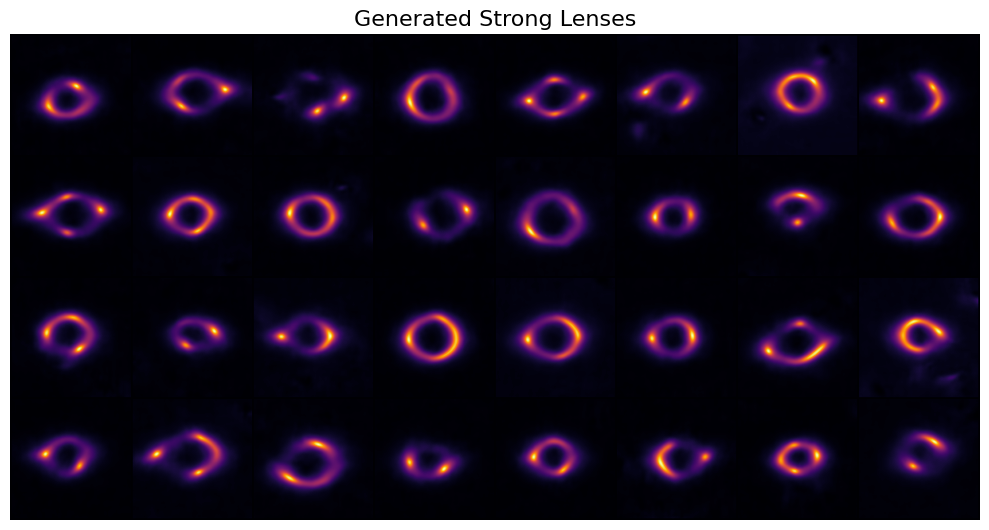

In [ ]:
def plot_grid_from_disk(folder_path="generated_lenses", num_images=64, nrow=8):
    """Loads saved .pt tensors from disk and plots them in a grid."""
    
    # 1. Find all the saved .pt files and sort them
    pt_files = sorted(glob.glob(os.path.join(folder_path, "sample_*.pt")))
    
    if not pt_files:
        print("No .pt files found! Check your directory.")
        return
        
    # Limit to the number we want to plot
    pt_files = pt_files[:num_images]
    
    # 2. Load them into a single batch tensor
    loaded_tensors = [torch.load(f, map_location='cpu') for f in pt_files]
    pixel_images = torch.stack(loaded_tensors)
    
    # 3. Create the visual grid
    grid = make_grid(pixel_images, nrow=nrow, padding=2, normalize=True, scale_each=True)
    
    # ---> THE FIX <---
    # make_grid outputs (3, H, W). We take only the first channel: (H, W)
    grid_np = grid[0].numpy() 
    
    plt.figure(figsize=(10, 10))
    # Because grid_np is now strictly 2D, the cmap argument will be respected!
    plt.imshow(grid_np, cmap='inferno') 
    plt.axis('off')
    plt.title("Generated Strong Lenses", fontsize=16)
    plt.tight_layout()
    plt.show()

# Run it!
plot_grid_from_disk(folder_path="generated_lenses", num_images=64, nrow=8)

In [ ]:
def calculate_fid(real_dataloader, generated_folder="generated_lenses", num_gen_samples=5000, device='cuda'):
    """Calculates FID between the real dataset and generated .pt samples."""
    print("Initializing FID Metric...")
    # feature=64 is faster and often sufficient, use 2048 for the standard paper implementation
    fid = FrechetInceptionDistance(feature=64).to(device) 
    
    # 1. Process Real Images
    print("Processing Real Images...")
    for batch in tqdm(real_dataloader, desc="Real Data"):
        # Assuming your dataloader returns (images, labels) or just images
        real_images = batch[0] if isinstance(batch, (list, tuple)) else batch
        real_images = real_images.to(device)
        
        # Convert 1-channel [0, 1] to 3-channel [0, 255] uint8
        if real_images.shape[1] == 1:
            real_images = real_images.repeat(1, 3, 1, 1)
        real_images_uint8 = (real_images * 255).to(torch.uint8)
        
        fid.update(real_images_uint8, real=True)

    # 2. Process Generated Images
    print("Processing Generated Images...")
    pt_files = sorted(glob.glob(os.path.join(generated_folder, "sample_*.pt")))[:num_gen_samples]
    
    # Process in batches to save memory
    batch_size = 32
    for i in tqdm(range(0, len(pt_files), batch_size), desc="Gen Data"):
        batch_files = pt_files[i:i+batch_size]
        gen_batch = torch.stack([torch.load(f, map_location=device) for f in batch_files])
        
        # Convert to 3-channel [0, 255] uint8
        if gen_batch.shape[1] == 1:
            gen_batch = gen_batch.repeat(1, 3, 1, 1)
        gen_batch_uint8 = (gen_batch * 255).to(torch.uint8)
        
        fid.update(gen_batch_uint8, real=False)

    # 3. Compute Final Score
    fid_score = fid.compute()
    print(f"\nFinal FID Score: {fid_score.item():.4f}")
    return fid_score.item()

# Example Usage:
# You will need to pass your training DataLoader here
fid_value = calculate_fid(real_dataloader=train_loader, generated_folder="generated_lenses", num_gen_samples=5000)

Initializing FID Metric...


Processing Real Images...


Real Data: 100%|██████████| 282/282 [00:03<00:00, 72.07it/s]


Processing Generated Images...


Gen Data: 100%|██████████| 157/157 [00:48<00:00,  3.22it/s]


Final FID Score: 5.8864


In [ ]:
def check_memorization(real_dataloader, generated_folder="generated_lenses", num_to_check=16, subset_real=1000, device='cuda'):
    """Finds the nearest neighbor in the real dataset for a few generated samples."""
    print("Initializing Memorization Check...")
    ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
    
    # Load a few generated samples
    pt_files = sorted(glob.glob(os.path.join(generated_folder, "sample_*.pt")))[:num_to_check]
    gen_samples = torch.stack([torch.load(f, map_location=device) for f in pt_files])
    
    # Collect a subset of real images to compare against
    real_subset = []
    count = 0
    for batch in real_dataloader:
        imgs = batch[0] if isinstance(batch, (list, tuple)) else batch
        real_subset.append(imgs.to(device))
        count += imgs.size(0)
        if count >= subset_real:
            break
    real_subset = torch.cat(real_subset, dim=0)[:subset_real]
    
    max_ssim_scores = []
    
    print(f"Comparing {num_to_check} generated images against {subset_real} real images...")
    for i in range(num_to_check):
        gen_img = gen_samples[i:i+1] # Shape: (1, 1, H, W)
        
        # We need to expand the generated image to match the real subset batch size
        gen_img_expanded = gen_img.expand(subset_real, -1, -1, -1)
        
        # Compute SSIM between this generated image and ALL real images in the subset
        # Note: torchmetrics SSIM averages over the batch by default, we need it per-image
        # A quick workaround is computing it in a loop if memory/implementation is strict, 
        # but for speed we will loop through the real images.
        best_ssim = -1.0
        
        for j in range(subset_real):
            score = ssim_metric(gen_img, real_subset[j:j+1]).item()
            if score > best_ssim:
                best_ssim = score
                
        max_ssim_scores.append(best_ssim)
        print(f"Gen Sample {i} -> Highest SSIM with Real Data: {best_ssim:.4f}")
        
    avg_max_ssim = sum(max_ssim_scores) / len(max_ssim_scores)
    print(f"\nAverage Nearest-Neighbor SSIM: {avg_max_ssim:.4f}")

# Example Usage:
check_memorization(real_dataloader=train_loader, generated_folder="generated_lenses")

Initializing Memorization Check...
Comparing 16 generated images against 1000 real images...
Gen Sample 0 -> Highest SSIM with Real Data: 0.8694


Gen Sample 1 -> Highest SSIM with Real Data: 0.8839
Gen Sample 2 -> Highest SSIM with Real Data: 0.8725
Gen Sample 3 -> Highest SSIM with Real Data: 0.8721
Gen Sample 4 -> Highest SSIM with Real Data: 0.8668
Gen Sample 5 -> Highest SSIM with Real Data: 0.8957
Gen Sample 6 -> Highest SSIM with Real Data: 0.8763
Gen Sample 7 -> Highest SSIM with Real Data: 0.8683
Gen Sample 8 -> Highest SSIM with Real Data: 0.8671
Gen Sample 9 -> Highest SSIM with Real Data: 0.8475
Gen Sample 10 -> Highest SSIM with Real Data: 0.8683
Gen Sample 11 -> Highest SSIM with Real Data: 0.8757
Gen Sample 12 -> Highest SSIM with Real Data: 0.8058
Gen Sample 13 -> Highest SSIM with Real Data: 0.8951
Gen Sample 14 -> Highest SSIM with Real Data: 0.8826
Gen Sample 15 -> Highest SSIM with Real Data: 0.8711

Average Nearest-Neighbor SSIM: 0.8699
